# Graph evaluation — `full_full`, compressed domain embeddings

A deliberately small first-stage experiment on the LORAX folds.

**Fixed representation:** full putative ESM-1b 1280 and ChemBERTa-77M 384 are loaded first. For every `(regime, fold, seed)`, PCA32/PCA16 is fitted on **all nodes present in the original train split**, before any shared/disjoint division, and then applied to all nodes. Validation/test-only nodes never fit PCA; shared and disjoint use the same full-train PCA rule.

**Only two forks:** evaluation regime (`transductive` / cold-molecule `inductive_molecule`) and supervision protocol (`shared` / `disjoint`). Architecture and message passing are fixed: GraphSAGE, signed edges. Each graph configuration can be repeated for three seeds; tables, plots and paired contrasts report 95% Student-t confidence intervals. This notebook intentionally stops before architecture or representation sweeps.

In [9]:
from pathlib import Path
import json, subprocess, sys, time, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from scipy.stats import t as student_t

ROOT = Path.cwd()
while not (ROOT / "pyproject.toml").exists():
    if ROOT.parent == ROOT:
        raise RuntimeError("Run this notebook from inside the orbind repository")
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from orbind.dataset import metrics

PROTEIN_SOURCE = ROOT / "data/external/lorax_m2or/esm1b_650m_mean_lorax.npz"
MOLECULE_SOURCE = ROOT / "data/embeddings/molecules/chemberta_77m_lorax.pkl"
PROTEIN_PCA_DIM, MOLECULE_PCA_DIM = 32, 16
RESULT_ROOT = ROOT / "results/graph/full_full/compression"
FIGURES_DIR = ROOT / "notebooks/figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
# Chart palette (dataviz): probe-split by hue (blue=shared, orange=disjoint),
# raw=solid vs graph-mol=light tint; baseline is neutral grey.
VARIANT_C = {"shared_raw": "#2a78d6", "shared_enriched": "#8fbcef",
             "disjoint_raw": "#eb6834", "disjoint_enriched": "#f4a683"}
BASE_C = "#9a9a95"
REFERENCE_HIDDEN = 256       # historical full_full default; never change this reference
COMPACT_HIDDEN = True        # True -> 64 for this experiment; False -> historical 256
HIDDEN = 64 if COMPACT_HIDDEN else REFERENCE_HIDDEN
PROFILE_ROOT = RESULT_ROOT / f"h{HIDDEN}"
RUNS_DIR, LOGS_DIR, TABLES_DIR = [PROFILE_ROOT / x for x in ("runs", "logs", "tables")]
for p in (RUNS_DIR, LOGS_DIR, TABLES_DIR): p.mkdir(parents=True, exist_ok=True)

assert PROTEIN_SOURCE.exists(), PROTEIN_SOURCE
assert MOLECULE_SOURCE.exists(), MOLECULE_SOURCE
print(f"raw sources: protein=1280 -> PCA{PROTEIN_PCA_DIM}; molecule=384 -> PCA{MOLECULE_PCA_DIM}")
print("PCA fit scope: every node in original train, before shared/disjoint split")
print(f"hidden={HIDDEN} (historical reference={REFERENCE_HIDDEN})")
print("results:", PROFILE_ROOT.relative_to(ROOT))

raw sources: protein=1280 -> PCA32; molecule=384 -> PCA16
PCA fit scope: every node in original train, before shared/disjoint split
hidden=64 (historical reference=256)
results: results\graph\full_full_compressed\h64


## Experiment contract and cache

Every `(configuration, seed)` owns a separate run directory, so checkpoints cannot overwrite one another. A run is cached only when its checkpoint is readable and records the expected embedding paths. Logs and the incremental status table live under the same experiment root.

Set `RUN_MISSING = True` to launch only absent/invalid runs. Re-running the cell skips valid cached runs.

`COMPACT_HIDDEN=True` selects hidden=64. Set it to `False` to return to the historical hidden=256 reference; each width has an isolated cache (`h64/` or `h256/`). The trainer itself retains its original default of 256.


Pilot mode uses only seed 42 (`INCLUDE_REPLICATIONS=False`). After inspecting it, set `INCLUDE_REPLICATIONS=True`; the cache keeps seed 42 and launches only seeds 43 and 44. Confidence intervals appear automatically once replications are enabled.


In [10]:
PILOT_SEEDS = [42]
REPLICATION_SEEDS = [43, 44]
INCLUDE_REPLICATIONS = True  # later set True: cached seed 42 is skipped, only 43/44 run
SEEDS = PILOT_SEEDS + (REPLICATION_SEEDS if INCLUDE_REPLICATIONS else [])
SHOW_CI = len(SEEDS) >= 2
EPOCHS = 600
RUN_MISSING = True  # change to True when ready

CONFIGS = [
    dict(config="transductive_shared_raw", regime="transductive", disjoint=False,
         enriched=False, variant="shared_raw", display="shared · raw mol"),
    dict(config="transductive_shared_enriched", regime="transductive", disjoint=False,
         enriched=True, variant="shared_enriched", display="shared · graph mol"),
    dict(config="transductive_disjoint_raw", regime="transductive", disjoint=True,
         enriched=False, variant="disjoint_raw", display="disjoint · raw mol"),
    dict(config="transductive_disjoint_enriched", regime="transductive", disjoint=True,
         enriched=True, variant="disjoint_enriched", display="disjoint ? graph mol"),
    dict(config="inductive_shared_raw", regime="inductive_molecule", disjoint=False,
         enriched=False, variant="shared_raw", display="shared · raw mol"),
    dict(config="inductive_disjoint_raw", regime="inductive_molecule", disjoint=True,
         enriched=False, variant="disjoint_raw", display="disjoint · raw mol"),
]
SPECS = pd.DataFrame([{**cfg, "seed": seed} for cfg in CONFIGS for seed in SEEDS])

def run_dir(row):
    return RUNS_DIR / row.config / f"seed_{int(row.seed)}"

def checkpoint_path(row):
    variant = "signed"
    if bool(row.enriched): variant += "_transductive_exp"
    if bool(row.disjoint): variant += "_disjoint"
    name = f"gnn_{variant}_unentangled_boost_{row.regime}_fold1.pt"
    return run_dir(row) / "checkpoints" / name

def cache_valid(row):
    path = checkpoint_path(row)
    if not path.exists(): return False
    try:
        ck = torch.load(path, map_location="cpu", weights_only=False)
        cfg = ck.get("config", {})
        return (ck.get("seed", int(row.seed)) == int(row.seed)
                and cfg.get("protein_embeddings") == PROTEIN_SOURCE.relative_to(ROOT).as_posix()
                and cfg.get("molecule_embeddings") == MOLECULE_SOURCE.relative_to(ROOT).as_posix()
                and cfg.get("hidden") == HIDDEN
                and cfg.get("epochs") == EPOCHS
                and cfg.get("protein_pca_dim") == PROTEIN_PCA_DIM
                and cfg.get("molecule_pca_dim") == MOLECULE_PCA_DIM
                and cfg.get("pca_fit_scope") == "full original train before disjoint split")
    except Exception:
        return False

def command(row):
    out = run_dir(row)
    cmd = [sys.executable, str(ROOT / "scripts/modeling/train/train_graph_full_full.py"),
           "--arch", "gnn", "--mp_mode", "signed", "--regime", row.regime,
           "--fold", "1", "--seed", str(int(row.seed)), "--epochs", str(EPOCHS),
           "--hidden", str(HIDDEN), "--lr", "0.001", "--grad-clip", "1.0", "--lr-scheduler",
           "--scheduler-patience", "100", "--scheduler-factor", "0.5",
           "--diagnostics", "--deterministic",
           "--protein-embeddings", PROTEIN_SOURCE.relative_to(ROOT).as_posix(),
           "--molecule-embeddings", MOLECULE_SOURCE.relative_to(ROOT).as_posix(),
           "--protein-pca-dim", str(PROTEIN_PCA_DIM),
           "--molecule-pca-dim", str(MOLECULE_PCA_DIM),
           "--results-dir", str(out.relative_to(ROOT)).replace("\\", "/")]
    if bool(row.enriched): cmd.append("--transductive-exp")
    if bool(row.disjoint): cmd.append("--disjoint-probe-train")
    return cmd

def status_table():
    rows=[]
    for row in SPECS.itertuples(index=False):
        p=checkpoint_path(row)
        rows.append({"config":row.config,"regime":row.regime,"variant":row.variant, "display":row.display,
                     "seed":row.seed,"cached":cache_valid(row),"checkpoint":str(p.relative_to(ROOT))})
    out=pd.DataFrame(rows); out.to_csv(TABLES_DIR/"run_status.csv",index=False)
    return out

if RUN_MISSING:
    for row in SPECS.itertuples(index=False):
        if cache_valid(row):
            print("CACHED", row.config, row.seed); continue
        rd=run_dir(row); rd.mkdir(parents=True,exist_ok=True)
        log=LOGS_DIR/f"{row.config}__seed_{row.seed}.log"
        print("RUN",row.config,row.seed,"->",log.relative_to(ROOT),flush=True)
        with log.open("w",encoding="utf-8") as fh:
            proc=subprocess.run(command(row),cwd=ROOT,stdout=fh,stderr=subprocess.STDOUT,text=True)
        if proc.returncode != 0:
            print("FAILED",row.config,row.seed,"see",log.relative_to(ROOT)); break
        print("DONE",row.config,row.seed,flush=True)
        status_table()

STATUS=status_table()
print(f"cached {int(STATUS.cached.sum())}/{len(STATUS)} runs "
      f"({', '.join(sorted(STATUS.loc[STATUS.cached,'config'].unique()))})")

CACHED transductive_shared_raw 42
CACHED transductive_shared_raw 43
CACHED transductive_shared_raw 44
CACHED transductive_shared_enriched 42
CACHED transductive_shared_enriched 43
CACHED transductive_shared_enriched 44
CACHED transductive_disjoint_raw 42
CACHED transductive_disjoint_raw 43
CACHED transductive_disjoint_raw 44
CACHED transductive_disjoint_enriched 42
CACHED transductive_disjoint_enriched 43
CACHED transductive_disjoint_enriched 44
CACHED inductive_shared_raw 42
CACHED inductive_shared_raw 43
CACHED inductive_shared_raw 44
CACHED inductive_disjoint_raw 42
CACHED inductive_disjoint_raw 43
CACHED inductive_disjoint_raw 44
cached 18/18 runs (inductive_disjoint_raw, inductive_shared_raw, transductive_disjoint_enriched, transductive_disjoint_raw, transductive_shared_enriched, transductive_shared_raw)


## Cached test results with 95% CI

Intervals quantify variation across the three complete training runs. With only three seeds they are necessarily wide; Student-t (`df=2`) is used rather than a normal approximation. Model selection remains based on validation AUPRC inside each run; the test set is evaluated only after restoring the best-validation checkpoint.

The grey reference is a no-graph XGBoost on the original full 384+1280 embeddings: five LORAX folds for transductive and five cold-split seeds for inductive.


In [11]:
METRICS = ["AUROC", "AUPRC", "MCC", "F1"]
# Point-estimate baseline (always present); wide: one row per regime, columns = metrics.
BASELINE = pd.read_csv(ROOT / "results/full_full/tables/baselines.csv").set_index("regime")
# Optional baseline 95% CI — only exists if the extra baseline resamples were run.
BASELINE_CI_PATH = ROOT / "results/full_full/tables/baselines_ci95.csv"
BASELINE_CI = pd.read_csv(BASELINE_CI_PATH) if BASELINE_CI_PATH.exists() else pd.DataFrame()

def ci95(x):
    x = np.asarray(x, dtype=float); n = np.isfinite(x).sum(); x = x[np.isfinite(x)]
    if n < 2:
        return pd.Series({"mean": x.mean() if n else np.nan, "sd": np.nan,
                          "ci_low": np.nan, "ci_high": np.nan, "n": n})
    mean = x.mean(); half = student_t.ppf(.975, n-1) * x.std(ddof=1) / np.sqrt(n)
    return pd.Series({"mean": mean, "sd": x.std(ddof=1),
                      "ci_low": mean-half, "ci_high": mean+half, "n": n})

rows = []
for spec in SPECS.itertuples(index=False):
    p = checkpoint_path(spec)
    if not cache_valid(spec): continue
    ck = torch.load(p, map_location="cpu", weights_only=False)
    y = ck["test_sup"][1].numpy(); score = np.asarray(ck["test_scores"])
    row = {"config":spec.config, "regime":spec.regime, "variant":spec.variant,
           "display":spec.display, "seed":spec.seed,
           "best_epoch":int(np.argmax([h["val_AUPRC"] for h in ck["decoder_history"]])+1)}
    row.update(metrics(y, score)); rows.append(row)
RUN_RESULTS = pd.DataFrame(rows)
RUN_RESULTS.to_csv(TABLES_DIR / "test_metrics_by_seed.csv", index=False)

if len(RUN_RESULTS):
    long = RUN_RESULTS.melt(id_vars=["config","regime","variant","display","seed"],
                            value_vars=METRICS, var_name="metric", value_name="value")
    SUMMARY = (long.groupby(["config","regime","variant","display","metric"])["value"]
               .apply(ci95).unstack().reset_index())
    SUMMARY.to_csv(TABLES_DIR / "test_metrics_ci95.csv", index=False)
else:
    SUMMARY = pd.DataFrame(); print("No complete cached graph runs yet. Set RUN_MISSING=True.")
if BASELINE_CI.empty:
    print("Baseline CI not found -> baseline shown as a point (no whisker).")
print(f"summary: {len(SUMMARY)} rows over {SUMMARY.config.nunique() if len(SUMMARY) else 0} configs")


summary: 24 rows over 6 configs


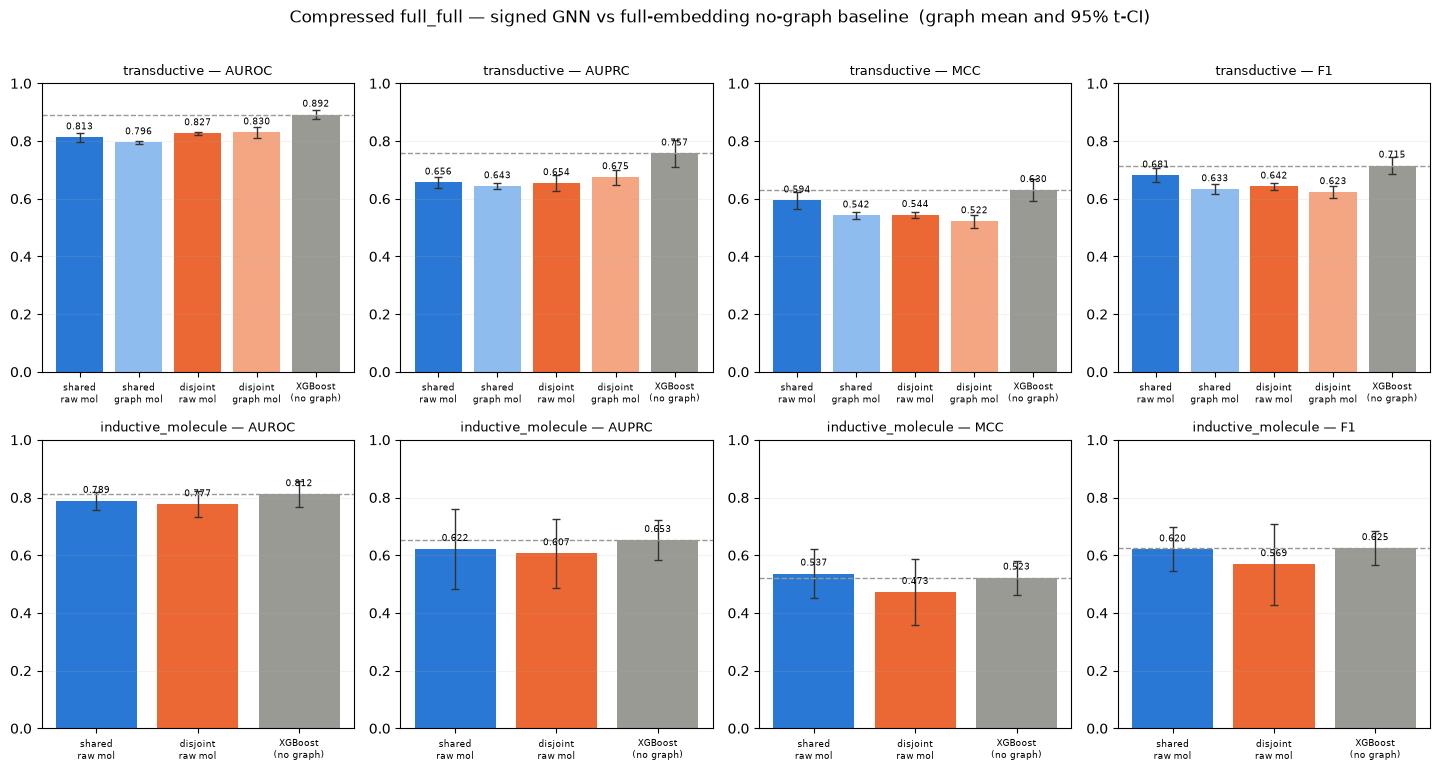

In [12]:
if len(SUMMARY):
    # Same layout as the full_full notebook: rows = regimes, cols = metrics,
    # grouped bars = graph variants + XGBoost no-graph baseline. Graph bars carry a
    # 95% t-CI whisker; the baseline whisker is drawn only if baselines_ci95.csv exists.
    regimes = ["transductive", "inductive_molecule"]
    graph_variants = {
        "transductive": ["shared_raw", "shared_enriched", "disjoint_raw", "disjoint_enriched"],
        "inductive_molecule": ["shared_raw", "disjoint_raw"],
    }
    labels = {"shared_raw": "shared\nraw mol", "shared_enriched": "shared\ngraph mol",
              "disjoint_raw": "disjoint\nraw mol", "disjoint_enriched": "disjoint\ngraph mol"}

    def base_ci(regime, metric):
        """(mean, lo, hi) for the no-graph baseline; lo/hi NaN when no CI file."""
        mean = float(BASELINE.loc[regime, metric])
        if len(BASELINE_CI):
            hit = BASELINE_CI[(BASELINE_CI.regime == regime) & (BASELINE_CI.metric == metric)]
            if len(hit):
                r = hit.iloc[0]
                return float(r["mean"]), float(r["ci_low"]), float(r["ci_high"])
        return mean, np.nan, np.nan

    fig, axes = plt.subplots(len(regimes), len(METRICS), figsize=(14.5, 7.6), squeeze=False)
    for ri, regime in enumerate(regimes):
        for mi, metric in enumerate(METRICS):
            ax = axes[ri, mi]
            variants = graph_variants[regime]
            d = (SUMMARY[(SUMMARY.regime == regime) & (SUMMARY.metric == metric)]
                 .set_index("variant").reindex(variants))
            b_mean, b_lo, b_hi = base_ci(regime, metric)
            vals = list(d["mean"].to_numpy(float)) + [b_mean]
            names = [labels[v] for v in variants] + ["XGBoost\n(no graph)"]
            colors = [VARIANT_C[v] for v in variants] + [BASE_C]
            # asymmetric 95% t-CI whiskers; NaN -> 0 so a bar without CI simply has no whisker
            lo = list(vals[:-1] - d["ci_low"].to_numpy(float)) + [b_mean - b_lo]
            hi = list(d["ci_high"].to_numpy(float) - vals[:-1]) + [b_hi - b_mean]
            yerr = np.vstack([np.nan_to_num(lo), np.nan_to_num(hi)]) if SHOW_CI else None
            bars = ax.bar(names, vals, color=colors,
                          yerr=yerr, error_kw=dict(ecolor="#33322f", capsize=3, lw=1))
            ax.axhline(b_mean, color=BASE_C, ls="--", lw=1)
            ax.set_title(f"{regime} — {metric}", fontsize=9)
            ax.set_ylim(0, 1); ax.grid(alpha=.15, axis="y")
            ax.tick_params(axis="x", labelsize=6.5)
            for b, v in zip(bars, vals):
                if np.isfinite(v):
                    ax.text(b.get_x() + b.get_width()/2, v + .02, f"{v:.3f}",
                            ha="center", va="bottom", fontsize=6.5)
    tail = "  (graph mean and 95% t-CI)" if SHOW_CI else "  (graph pilot seed 42)"
    fig.suptitle("Compressed full_full — signed GNN vs full-embedding no-graph baseline" + tail,
                 fontsize=12, y=1.01)
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / "graph_full_full_compressed_protocol.png", dpi=150, bbox_inches="tight")
    plt.show()


## Feature ladder — what does the graph actually add?

A single ordered comparison (no-graph → graph → graph + raw protein back), all probed
on the **same disjoint test edges** so only the feature set changes:

1. **compressed boost** — XGBoost on `[compressed mol | compressed prot]`, no graph at all.
2. **graph z_prot** — `[compressed mol | z_prot]` (exactly the *disjoint raw mol* run above).
3. **graph + compressed prot** — `[compressed mol | z_prot | compressed prot]`.
4. **graph + full prot** — `[compressed mol | z_prot | full ESM-1b 1280]`.
5. **full boost** — the current no-graph XGBoost on the full `[ChemBERTa 384 | ESM-1b 1280]`.

The generation cell **reuses the saved GNN encoders** (`best_state` in each disjoint_raw
checkpoint): `z_prot` is recomputed with a single forward pass, so no GNN is retrained —
only the XGBoost probes for the new feature sets are fit, then cached to CSV.

For every seed/regime the compressed blocks are reconstructed from the PCA saved in the checkpoint; that PCA was fitted on the complete original train before its disjoint division.


In [13]:
# --- generate the feature ladder (reuses saved encoders and their train-fitted PCA) ---
from orbind import lorax as L, hetero as H
from orbind.baselines import train_boost
from orbind.dataset import metrics as _metrics
MOL, PROT = H.MOL, H.PROT
SPEC_BARS = ["compressed", "graph_zprot", "graph+cprot", "graph+fullprot"]
SPECTRUM_CSV = TABLES_DIR / "feature_spectrum_by_seed.csv"

def _edge_feats(mol, prot_blocks, idx):
    m = mol[idx[0].numpy()]
    pcat = np.concatenate([b[idx[1].numpy()] for b in prot_blocks], axis=1)
    return np.concatenate([m, pcat], axis=1).astype(np.float32)

def _apply_saved_pca(x, meta):
    X = x.numpy().astype(np.float64)
    return ((X - np.asarray(meta["mean"], dtype=np.float64)) @
            np.asarray(meta["components"], dtype=np.float64).T).astype(np.float32)

def _need(df):
    have = set(zip(df.regime, df.seed, df.bar)) if len(df) else set()
    want = {(r.regime, int(r.seed), b)
            for r in SPECS[SPECS.variant == "disjoint_raw"].itertuples(index=False)
            if cache_valid(r) for b in SPEC_BARS}
    return want - have

SPECTRUM = pd.read_csv(SPECTRUM_CSV) if SPECTRUM_CSV.exists() else pd.DataFrame()

if _need(SPECTRUM):
    print("generating feature ladder (saved full-train PCA + saved encoders)...")
    esm_full, chem_full = L.load_embeddings(
        PROTEIN_SOURCE.relative_to(ROOT).as_posix(),
        MOLECULE_SOURCE.relative_to(ROOT).as_posix())
    rows = SPECTRUM.to_dict("records") if len(SPECTRUM) else []
    done = set(zip(SPECTRUM.regime, SPECTRUM.seed, SPECTRUM.bar)) if len(SPECTRUM) else set()
    for spec in SPECS[SPECS.variant == "disjoint_raw"].itertuples(index=False):
        if not cache_valid(spec): continue
        regime, seed = spec.regime, int(spec.seed)
        ck = torch.load(checkpoint_path(spec), map_location="cpu", weights_only=False)
        Xm_full_t, Xp_full_t, splits = L.build(regime, 1, esm_full, chem_full, seed=seed)
        Xm = _apply_saved_pca(Xm_full_t, ck["input_pca"]["molecule"])
        Xp = _apply_saved_pca(Xp_full_t, ck["input_pca"]["protein"])
        gnn_train, probe_train = H.split_train_for_probe(
            splits["train"], probe_frac=ck["config"]["probe_train_frac"], seed=seed + 101)
        mp_pos = torch.tensor(gnn_train["pos"].T, dtype=torch.long)
        mp_neg = torch.tensor(gnn_train["neg"].T, dtype=torch.long)
        eidx = H.edge_index_dict(mp_pos, mp_neg, mode="signed")
        sup_probe, sup_test = H.sup_edges(probe_train), H.sup_edges(splits["test"])
        x_dict = {MOL: torch.tensor(Xm), PROT: torch.tensor(Xp)}
        model = H.HeteroLink(hidden=HIDDEN, dropout=0.3, mp_mode="signed")
        with torch.no_grad(): model.encode(x_dict, eidx)
        model.load_state_dict(ck["best_state"]); model.eval()
        with torch.no_grad(): z = model.encode(x_dict, eidx)
        Zp, Xp_full = z[PROT].numpy(), Xp_full_t.numpy()
        ip, it = sup_probe[0], sup_test[0]
        ytr, yte = sup_probe[1].numpy(), sup_test[1].numpy()
        ladders = {"compressed": (Xm, [Xp]), "graph_zprot": (Xm, [Zp]),
                   "graph+cprot": (Xm, [Zp, Xp]), "graph+fullprot": (Xm, [Zp, Xp_full])}
        for bar, (mol, pb) in ladders.items():
            if (regime, seed, bar) in done: continue
            if bar == "graph_zprot":
                m = _metrics(yte, ck["test_scores"])
            else:
                sc = train_boost(_edge_feats(mol, pb, ip), ytr,
                                 _edge_feats(mol, pb, it), seed=seed)
                m = _metrics(yte, sc)
            dim = _edge_feats(mol, pb, it).shape[1]
            rows.append({"regime":regime,"seed":seed,"bar":bar,"dim":dim,
                         **{k:float(m[k]) for k in METRICS}})
            print(f"  {regime:20s} seed {seed} {bar:16s} dim={dim:5d} " +
                  " ".join(f"{k}={m[k]:.3f}" for k in METRICS))
    SPECTRUM = pd.DataFrame(rows); SPECTRUM.to_csv(SPECTRUM_CSV, index=False)

print(f"feature ladder: {len(SPECTRUM)} rows")


feature ladder: 24 rows


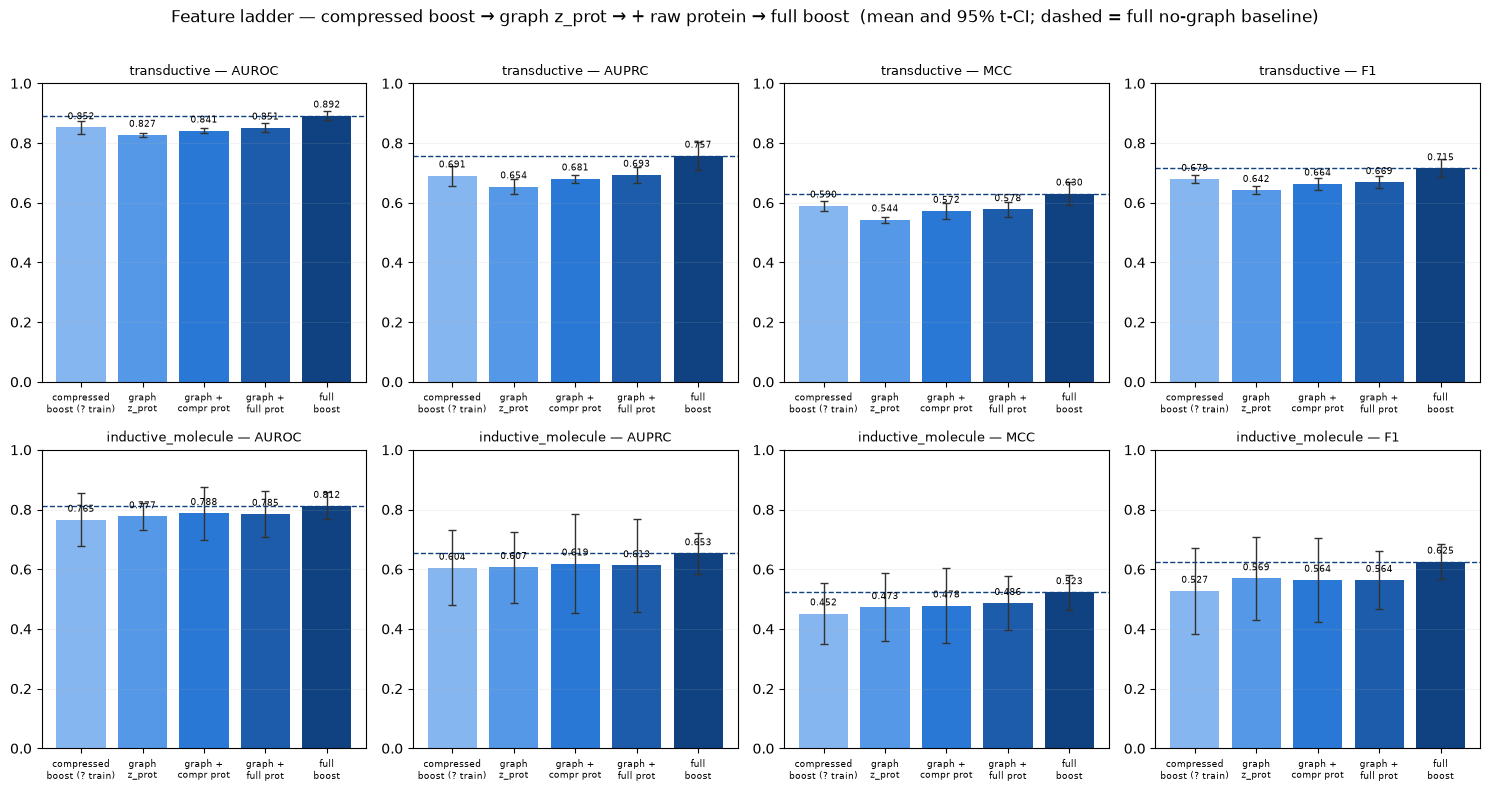

In [14]:
# --- feature-ladder chart: 5 ordered bars per (regime, metric) with 95% t-CI ---
BARS = ["compressed", "graph_zprot", "graph+cprot", "graph+fullprot", "full"]
BAR_LABEL = {"compressed": "compressed\nboost (? train)", "graph_zprot": "graph\nz_prot",
             "graph+cprot": "graph +\ncompr prot", "graph+fullprot": "graph +\nfull prot",
             "full": "full\nboost"}
# ordinal blue ramp: feature richness light -> dark
BAR_C = {"compressed": "#86b6ef", "graph_zprot": "#5598e7", "graph+cprot": "#2a78d6",
         "graph+fullprot": "#1c5cab", "full": "#104281"}

def _agg(regime, metric, bar):
    if bar == "full":
        mean = float(BASELINE.loc[regime, metric])
        if len(BASELINE_CI):
            hit = BASELINE_CI[(BASELINE_CI.regime == regime) & (BASELINE_CI.metric == metric)]
            if len(hit):
                r = hit.iloc[0]; return mean, float(r["ci_low"]), float(r["ci_high"])
        return mean, np.nan, np.nan
    d = SPECTRUM[(SPECTRUM.regime == regime) & (SPECTRUM.bar == bar)]
    if not len(d):
        return np.nan, np.nan, np.nan
    s = ci95(d[metric].to_numpy())
    return float(s["mean"]), float(s["ci_low"]), float(s["ci_high"])

if len(SPECTRUM):
    regimes = ["transductive", "inductive_molecule"]
    fig, axes = plt.subplots(len(regimes), len(METRICS), figsize=(15, 7.8), squeeze=False)
    for ri, regime in enumerate(regimes):
        for mi, metric in enumerate(METRICS):
            ax = axes[ri, mi]
            means, los, his = zip(*[_agg(regime, metric, b) for b in BARS])
            means = np.array(means, float)
            yerr = np.vstack([np.nan_to_num(means - np.array(los, float)),
                              np.nan_to_num(np.array(his, float) - means)])
            x = np.arange(len(BARS))
            ax.bar(x, means, color=[BAR_C[b] for b in BARS],
                   yerr=yerr, error_kw=dict(ecolor="#33322f", capsize=3, lw=1))
            ax.axhline(float(BASELINE.loc[regime, metric]), color=BAR_C["full"], ls="--", lw=1)
            ax.set_title(f"{regime} — {metric}", fontsize=9); ax.set_ylim(0, 1)
            ax.grid(alpha=.15, axis="y")
            ax.set_xticks(x); ax.set_xticklabels([BAR_LABEL[b] for b in BARS], fontsize=6.5)
            for xi, v in zip(x, means):
                if np.isfinite(v):
                    ax.text(xi, v + .02, f"{v:.3f}", ha="center", va="bottom", fontsize=6.5)
    fig.suptitle("Feature ladder — compressed boost → graph z_prot → + raw protein → full boost"
                 "  (mean and 95% t-CI; dashed = full no-graph baseline)", fontsize=12, y=1.01)
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / "graph_full_full_compressed_ladder.png", dpi=150, bbox_inches="tight")
    plt.show()

## Stop point / next decision

This notebook deliberately ends after the two foundational questions:

1. Does the compressed representation remain useful in transductive and cold-molecule evaluation?
2. Does the apparent graph benefit survive disjoint GNN/booster supervision?

Only after these intervals are available should we choose the next branch — e.g. compare against uncompressed features, test enriched molecule embeddings in transductive/shared, or vary architecture. Do not add all three at once.

## Shared-raw feature ladder ? full-train booster

This is the direct counterpart to the disjoint ladder above, but it starts from the
saved **shared raw** checkpoints. PCA is still the checkpoint PCA fitted on every
node in the original train split. The GNN encoder is reused without retraining, and
every XGBoost probe in this section is fitted on the **complete train pair set**.

The ordered comparison is:

1. **compressed boost (full train)** ? `[mol PCA16 | prot PCA32]`;
2. **graph z_prot (full train)** ? `[mol PCA16 | z_prot]`, identical to the saved shared-raw probe;
3. **graph + compressed prot (full train)** ? `[mol PCA16 | z_prot | prot PCA32]`;
4. **graph + full prot (full train)** ? `[mol PCA16 | z_prot | full ESM-1b 1280]`;
5. **full boost** ? existing no-graph full-embedding reference.

This section has its own cache and does not alter the disjoint results.


In [15]:
# --- shared-raw ladder: reuse encoders, fit boosters on the complete train ---
SHARED_BARS = ["compressed_full", "graph_zprot_shared", "graph+cprot_shared", "graph+fullprot_shared"]
SHARED_SPECTRUM_CSV = TABLES_DIR / "feature_spectrum_shared_fulltrain_by_seed.csv"

SHARED_SPECTRUM = (pd.read_csv(SHARED_SPECTRUM_CSV)
                   if SHARED_SPECTRUM_CSV.exists() else pd.DataFrame())
shared_done = (set(zip(SHARED_SPECTRUM.regime, SHARED_SPECTRUM.seed, SHARED_SPECTRUM.bar))
               if len(SHARED_SPECTRUM) else set())
shared_want = {(r.regime, int(r.seed), bar)
               for r in SPECS[SPECS.variant == "shared_raw"].itertuples(index=False)
               if cache_valid(r) for bar in SHARED_BARS}

if shared_want - shared_done:
    print("generating shared/full-train feature ladder (saved PCA + saved encoders)...")
    esm_full, chem_full = L.load_embeddings(
        PROTEIN_SOURCE.relative_to(ROOT).as_posix(),
        MOLECULE_SOURCE.relative_to(ROOT).as_posix())
    shared_rows = SHARED_SPECTRUM.to_dict("records") if len(SHARED_SPECTRUM) else []
    for spec in SPECS[SPECS.variant == "shared_raw"].itertuples(index=False):
        if not cache_valid(spec):
            continue
        regime, seed = spec.regime, int(spec.seed)
        ck = torch.load(checkpoint_path(spec), map_location="cpu", weights_only=False)
        Xm_full_t, Xp_full_t, splits = L.build(regime, 1, esm_full, chem_full, seed=seed)
        Xm = _apply_saved_pca(Xm_full_t, ck["input_pca"]["molecule"])
        Xp = _apply_saved_pca(Xp_full_t, ck["input_pca"]["protein"])

        train_pairs = splits["train"]
        mp_pos = torch.tensor(train_pairs["pos"].T, dtype=torch.long)
        mp_neg = torch.tensor(train_pairs["neg"].T, dtype=torch.long)
        eidx = H.edge_index_dict(mp_pos, mp_neg, mode="signed")
        sup_train, sup_test = H.sup_edges(train_pairs), H.sup_edges(splits["test"])
        x_dict = {MOL: torch.tensor(Xm), PROT: torch.tensor(Xp)}
        model = H.HeteroLink(hidden=HIDDEN, dropout=0.3, mp_mode="signed")
        with torch.no_grad():
            model.encode(x_dict, eidx)
        model.load_state_dict(ck["best_state"]); model.eval()
        with torch.no_grad():
            z = model.encode(x_dict, eidx)

        Zp, Xp_full = z[PROT].numpy(), Xp_full_t.numpy()
        itr, ite = sup_train[0], sup_test[0]
        ytr, yte = sup_train[1].numpy(), sup_test[1].numpy()
        ladders = {
            "compressed_full": (Xm, [Xp]),
            "graph_zprot_shared": (Xm, [Zp]),
            "graph+cprot_shared": (Xm, [Zp, Xp]),
            "graph+fullprot_shared": (Xm, [Zp, Xp_full]),
        }
        for bar, (mol, prot_blocks) in ladders.items():
            if (regime, seed, bar) in shared_done:
                continue
            if bar == "graph_zprot_shared":
                m = _metrics(yte, ck["test_scores"])
            else:
                score = train_boost(_edge_feats(mol, prot_blocks, itr), ytr,
                                    _edge_feats(mol, prot_blocks, ite), seed=seed)
                m = _metrics(yte, score)
            dim = _edge_feats(mol, prot_blocks, ite).shape[1]
            shared_rows.append({"regime":regime, "seed":seed, "bar":bar, "dim":dim,
                                **{k:float(m[k]) for k in METRICS}})
            print(f"  {regime:20s} seed {seed} {bar:23s} dim={dim:5d} " +
                  " ".join(f"{k}={m[k]:.3f}" for k in METRICS))
    SHARED_SPECTRUM = pd.DataFrame(shared_rows)
    SHARED_SPECTRUM.to_csv(SHARED_SPECTRUM_CSV, index=False)

print(f"shared/full-train ladder: {len(SHARED_SPECTRUM)} rows")


shared/full-train ladder: 24 rows


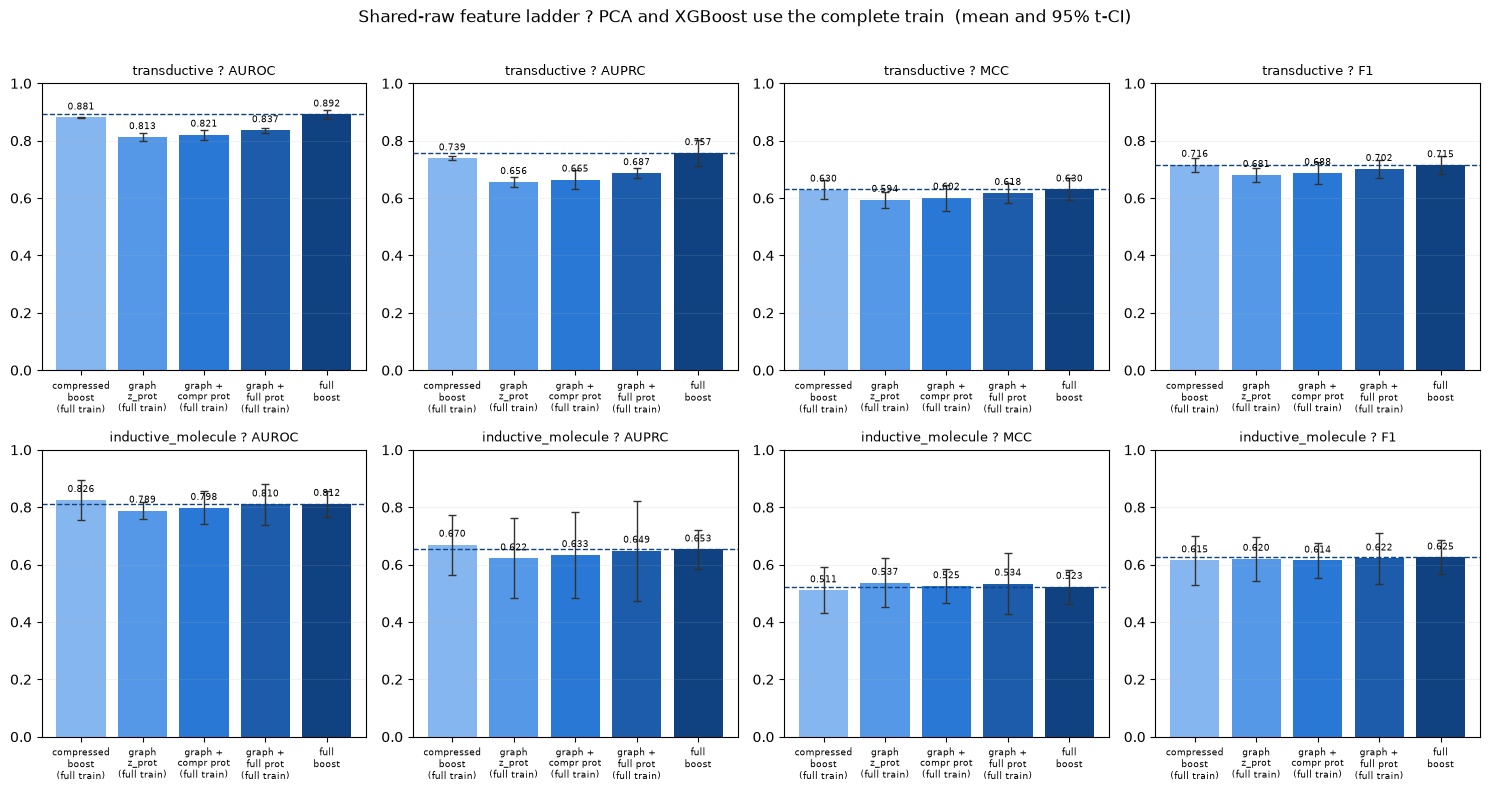

In [16]:
# --- shared/full-train ladder chart ---
SHARED_PLOT_BARS = [*SHARED_BARS, "full"]
SHARED_LABEL = {
    "compressed_full":"compressed\nboost\n(full train)",
    "graph_zprot_shared":"graph\nz_prot\n(full train)",
    "graph+cprot_shared":"graph +\ncompr prot\n(full train)",
    "graph+fullprot_shared":"graph +\nfull prot\n(full train)",
    "full":"full\nboost",
}
SHARED_C = {
    "compressed_full":"#86b6ef", "graph_zprot_shared":"#5598e7",
    "graph+cprot_shared":"#2a78d6", "graph+fullprot_shared":"#1c5cab",
    "full":"#104281",
}

def _shared_agg(regime, metric, bar):
    if bar == "full":
        mean = float(BASELINE.loc[regime, metric])
        if len(BASELINE_CI):
            hit = BASELINE_CI[(BASELINE_CI.regime == regime) & (BASELINE_CI.metric == metric)]
            if len(hit):
                row = hit.iloc[0]
                return mean, float(row["ci_low"]), float(row["ci_high"])
        return mean, np.nan, np.nan
    d = SHARED_SPECTRUM[(SHARED_SPECTRUM.regime == regime) &
                        (SHARED_SPECTRUM.bar == bar)]
    if not len(d):
        return np.nan, np.nan, np.nan
    stat = ci95(d[metric].to_numpy())
    return float(stat["mean"]), float(stat["ci_low"]), float(stat["ci_high"])

if len(SHARED_SPECTRUM):
    regimes = ["transductive", "inductive_molecule"]
    fig, axes = plt.subplots(2, len(METRICS), figsize=(15, 7.8), squeeze=False)
    for ri, regime in enumerate(regimes):
        for mi, metric in enumerate(METRICS):
            ax = axes[ri, mi]
            means, lows, highs = zip(*[_shared_agg(regime, metric, b)
                                       for b in SHARED_PLOT_BARS])
            means = np.asarray(means, float)
            yerr = np.vstack([np.nan_to_num(means-np.asarray(lows, float)),
                              np.nan_to_num(np.asarray(highs, float)-means)])
            x = np.arange(len(SHARED_PLOT_BARS))
            ax.bar(x, means, color=[SHARED_C[b] for b in SHARED_PLOT_BARS],
                   yerr=yerr, error_kw=dict(ecolor="#33322f", capsize=3, lw=1))
            ax.axhline(float(BASELINE.loc[regime, metric]), color=SHARED_C["full"], ls="--", lw=1)
            ax.set_title(f"{regime} ? {metric}", fontsize=9); ax.set_ylim(0, 1)
            ax.grid(alpha=.15, axis="y")
            ax.set_xticks(x); ax.set_xticklabels([SHARED_LABEL[b] for b in SHARED_PLOT_BARS], fontsize=6.3)
            for xi, value in zip(x, means):
                if np.isfinite(value):
                    ax.text(xi, value+.02, f"{value:.3f}", ha="center", va="bottom", fontsize=6.5)
    fig.suptitle("Shared-raw feature ladder ? PCA and XGBoost use the complete train"
                 "  (mean and 95% t-CI)", fontsize=12, y=1.01)
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / "graph_full_full_compressed_ladder_shared_fulltrain.png",
                dpi=150, bbox_inches="tight")
    plt.show()
